In [10]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# 配置路径
input_file = "../Data/Company_Perf_Stock_Data.xlsx"
output_file = "../Data/Data_Correlation.xlsx"        

def calculate_roe_mb_correlation():
    # 读取Excel及公司sheet
    try:
        excel = pd.ExcelFile(input_file)
        company_sheets = excel.sheet_names
    except FileNotFoundError:
        print("❌ 未找到原始数据文件，请检查路径")
        return None

    result_list = []
    for company_name in company_sheets:
        # 读取单公司数据
        comp_data = pd.read_excel(input_file, sheet_name=company_name, dtype={'Code': str})
        
        # 校验必要字段
        required_cols = ['Code', 'Name', 'Year', 'ROE', 'MB Ratio']
        if not all(col in comp_data.columns for col in required_cols):
            continue
        
        # 计算相关系数和P值
        roe = comp_data['ROE'].dropna()
        mb = comp_data['MB Ratio'].dropna()
        if len(roe) == len(mb) and len(roe) >= 3:
            corr = round(pearsonr(roe, mb)[0], 4)
            p_val = round(pearsonr(roe, mb)[1], 4)
        else:
            corr, p_val = np.nan, np.nan
        
        # 提取公司信息
        code = comp_data['Code'].iloc[0]
        year_range = f"{comp_data['Year'].min()}-{comp_data['Year'].max()}"
        result_list.append({
            'Code': code,
            'Name': company_name,
            'Year_Range': year_range,
            'ROE-MB_Ratio_Cor': corr,
            'ROE-MB_Ratio_P': p_val
        })

    # 整理表格
    if result_list:
        final_table = pd.DataFrame(result_list)[['Code', 'Name', 'Year_Range', 'ROE-MB_Ratio_Cor', 'ROE-MB_Ratio_P']]
        final_table.index = final_table.index + 1  # 展示时索引从1开始，不影响保存
        return final_table
    else:
        print("❌ 无有效数据生成表格")
        return None

# 执行计算
if __name__ == "__main__":
    correlation_result = calculate_roe_mb_correlation()
    if correlation_result is not None:
        # 展示结果
        print("=== 10家公司ROE与MB Ratio相关性计算结果 ===")
        display(correlation_result)
        
        # 保存表格
        try:
            correlation_result.to_excel(output_file, index=False)  # 关键：index=False不保存行索引
            print(f"\n✅ 结果表格已保存至：{output_file}（无序号列）")
        except Exception as e:
            print(f"\n❌ 保存失败，错误信息：{str(e)}")

=== 10家公司ROE与MB Ratio相关性计算结果 ===


,Code,Name,Year_Range,ROE-MB_Ratio_Cor,ROE-MB_Ratio_P
1,600519,贵州茅台,2020-2024,-0.9220,0.0258
2,000333,美的集团,2020-2024,0.7317,0.1599
3,300750,宁德时代,2020-2024,-0.5691,0.3166
4,002230,科大讯飞,2020-2024,0.8012,0.1031
5,002594,比亚迪,2020-2024,-0.9404,0.0173
6,600900,长江电力,2020-2024,0.5295,0.3588
7,601318,中国平安,2020-2024,0.9255,0.0242
8,600036,招商银行,2020-2024,0.2620,0.6703
9,600887,伊利股份,2020-2024,0.7956,0.1075
10,600031,三一重工,2020-2024,0.9663,0.0074



✅ 结果表格已保存至：../Data/Data_Correlation.xlsx（无序号列）


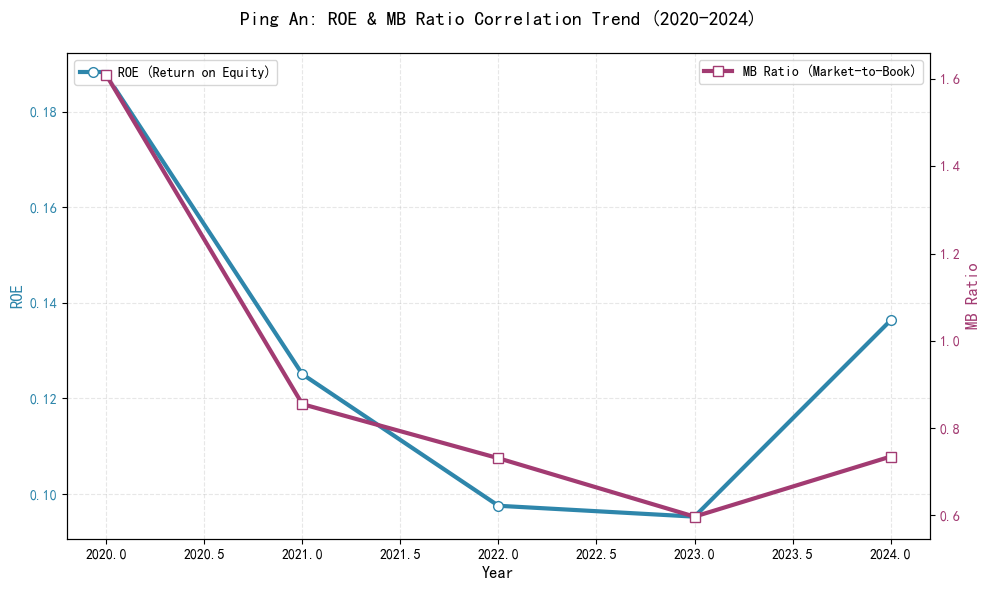

✅ Image saved to: ../Figures/Ping An_ROE_MB_Trend.png
   File name: Ping An_ROE_MB_Trend.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. 路径与参数配置
data_path = "../Data/Company_Perf_Stock_Data.xlsx" 
save_dir = "../Figures/" 
target_company_cn = "中国平安"  
target_company_en = "Ping An"   
img_name = f"{target_company_en}_ROE_MB_Trend.png" 
save_path = save_dir + img_name  

# 2. 读取并整理数据
def load_sorted_data(file_path, sheet_name):
    df = pd.read_excel(file_path, sheet_name=sheet_name, dtype={'Code': str})
    return df.sort_values('Year')[['Year', 'ROE', 'MB Ratio']]
data = load_sorted_data(data_path, target_company_cn)

# 3. 绘制双轴折线图
fig, ax1 = plt.subplots(figsize=(10, 6)) 

# 左轴：ROE（净资产收益率）
color_roe = '#2E86AB'
ax1.plot(data['Year'], data['ROE'], color=color_roe, linewidth=3,
         marker='o', markersize=7, markerfacecolor='white', markeredgecolor=color_roe,
         label='ROE (Return on Equity)')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('ROE', color=color_roe, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_roe, labelsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.grid(True, alpha=0.3, linestyle='--') 

# 右轴：MB Ratio（市净率）
ax2 = ax1.twinx() 
color_mb = '#A23B72'
ax2.plot(data['Year'], data['MB Ratio'], color=color_mb, linewidth=3,
         marker='s', markersize=7, markerfacecolor='white', markeredgecolor=color_mb,
         label='MB Ratio (Market-to-Book)')
ax2.set_ylabel('MB Ratio', color=color_mb, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_mb, labelsize=10)

# 图表标题与图例
ax1.set_title(f'{target_company_en}: ROE & MB Ratio Correlation Trend (2020-2024)', 
              fontsize=14, fontweight='bold', pad=20)

ax1.legend(loc='upper left', fontsize=10, frameon=True, shadow=False)
ax2.legend(loc='upper right', fontsize=10, frameon=True, shadow=False)

plt.tight_layout()

# 4. 预览与保存
display(fig)  
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')  
plt.close(fig)  

# 保存成功提示
print(f"✅ Image saved to: {save_path}")
print(f"   File name: {img_name}")

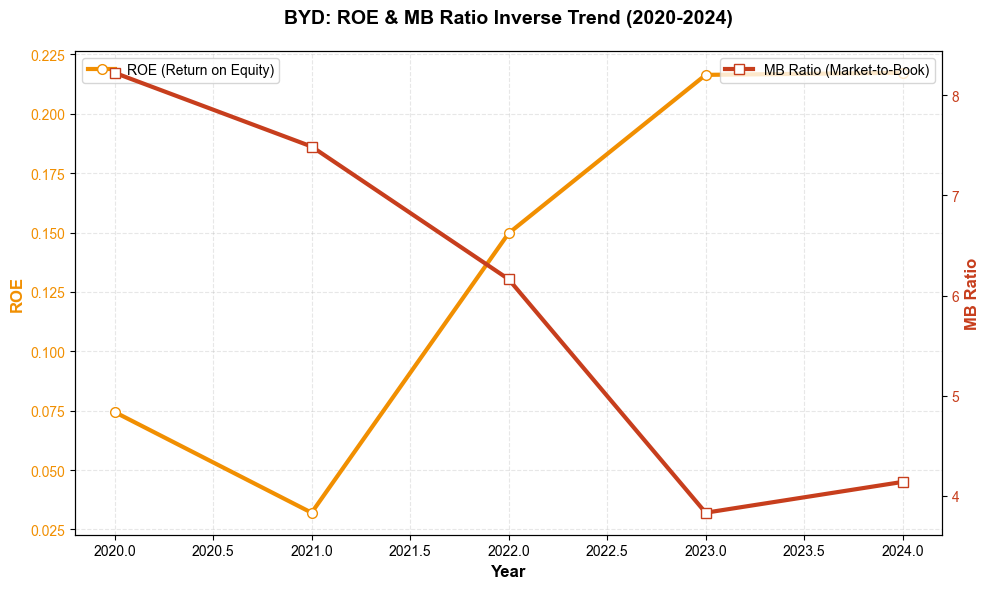

✅ Image saved to: ../Figures/BYD_ROE_MB_Trend.png
   File name: BYD_ROE_MB_Trend.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. 路径与参数配置
data_path = "../Data/Company_Perf_Stock_Data.xlsx" 
save_dir = "../Figures/"  
target_company_cn = "比亚迪"  
target_company_en = "BYD"     
img_name = f"{target_company_en}_ROE_MB_Trend.png" 
save_path = save_dir + img_name 
plt.rcParams['font.family'] = 'Arial'  

# 2. 读取并整理数据
def load_data(file_path, sheet_name):
    df = pd.read_excel(file_path, sheet_name=sheet_name, dtype={'Code': str})
    return df.sort_values('Year')[['Year', 'ROE', 'MB Ratio']]
data = load_data(data_path, target_company_cn)

# 3. 绘制双轴折线图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左轴：ROE
color_roe = '#F18F01'
ax1.plot(data['Year'], data['ROE'], color=color_roe, linewidth=3,
         marker='o', markersize=7, markerfacecolor='white', markeredgecolor=color_roe,
         label='ROE (Return on Equity)')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('ROE', color=color_roe, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_roe, labelsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper left', fontsize=10, frameon=True, shadow=False) 

# 右轴：MB Ratio
ax2 = ax1.twinx()
color_mb = '#C73E1D'
ax2.plot(data['Year'], data['MB Ratio'], color=color_mb, linewidth=3,
         marker='s', markersize=7, markerfacecolor='white', markeredgecolor=color_mb,
         label='MB Ratio (Market-to-Book)')
ax2.set_ylabel('MB Ratio', color=color_mb, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_mb, labelsize=10)
ax2.legend(loc='upper right', fontsize=10, frameon=True, shadow=False)  

# 图表标题
ax1.set_title(f'{target_company_en}: ROE & MB Ratio Inverse Trend (2020-2024)', 
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
display(fig)  

# 4. 保存图片
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)

# 保存成功提示
print(f"✅ Image saved to: {save_path}")
print(f"   File name: {img_name}")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

input_file = "../Data/Company_Perf_Stock_Data.xlsx"
output_file = "../Data/Data_Correlation.xlsx"

def calculate_roe_mb_correlation():
    # 读取Excel及公司sheet
    try:
        excel = pd.ExcelFile(input_file)
        company_sheets = excel.sheet_names
    except FileNotFoundError:
        print("未找到原始数据文件，请检查路径")
        return None

    result_list = []
    for company_name in company_sheets:
        comp_data = pd.read_excel(input_file, sheet_name=company_name, dtype={'Code': str})
        required_cols = ['Code', 'Name', 'Year', 'ROE', 'MB Ratio']
        if not all(col in comp_data.columns for col in required_cols):
            continue
        
        # 计算相关系数和P值
        roe = comp_data['ROE'].dropna()
        mb = comp_data['MB Ratio'].dropna()
        if len(roe) == len(mb) and len(roe) >= 3:
            corr = round(pearsonr(roe, mb)[0], 4)
            p_val = round(pearsonr(roe, mb)[1], 4)
        else:
            corr, p_val = np.nan, np.nan
        
        # 提取公司信息并添加结果
        code = comp_data['Code'].iloc[0]
        year_range = f"{comp_data['Year'].min()}-{comp_data['Year'].max()}"
        result_list.append({
            'Code': code,
            'Name': company_name,
            'Year_Range': year_range,
            'ROE-MB_Ratio_Cor': corr,
            'ROE-MB_Ratio_P': p_val
        })

    # 整理结果表格
    if result_list:
        final_table = pd.DataFrame(result_list)[['Code', 'Name', 'Year_Range', 'ROE-MB_Ratio_Cor', 'ROE-MB_Ratio_P']]
        final_table.index = final_table.index + 1
        return final_table
    else:
        print("无有效数据生成表格")
        return None

if __name__ == "__main__":
    correlation_result = calculate_roe_mb_correlation()
    if correlation_result is not None:
        print("=== 10家公司ROE与MB Ratio相关性计算结果 ===")
        display(correlation_result)
        
        # 保存结果
        try:
            correlation_result.to_excel(output_file, index=False)
            print(f"\n结果表格已保存至：{output_file}")
        except Exception as e:
            print(f"\n保存失败，错误信息：{str(e)}")

=== 10家公司ROE与MB Ratio相关性计算结果 ===


,Code,Name,Year_Range,ROE-MB_Ratio_Cor,ROE-MB_Ratio_P
1,600519,贵州茅台,2020-2024,-0.9220,0.0258
2,000333,美的集团,2020-2024,0.7317,0.1599
3,300750,宁德时代,2020-2024,-0.5691,0.3166
4,002230,科大讯飞,2020-2024,0.8012,0.1031
5,002594,比亚迪,2020-2024,-0.9404,0.0173
6,600900,长江电力,2020-2024,0.5295,0.3588
7,601318,中国平安,2020-2024,0.9255,0.0242
8,600036,招商银行,2020-2024,0.2620,0.6703
9,600887,伊利股份,2020-2024,0.7956,0.1075
10,600031,三一重工,2020-2024,0.9663,0.0074



结果表格已保存至：../Data/Data_Correlation1.0.xlsx（无序号列）
